In [52]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SUMMARY OF THE DATASET:

This dataset tracks 52,750 Blinkit grocery orders across 8 big Indian cities. It shows what people bought, how they paid, and how much they spent. It also shows that missing items cause lots of cancelled orders, and traffic makes the 10-minute delivery promise very hard to keep.

In [53]:
data = pd.read_csv('compressed_data.csv') # loading dataset
df = data.copy()

In [54]:
df.head(5)

,order_id,order_date,order_hour,city,dark_store_id,category,quantity,unit_price,order_value,distance_km,promised_delivery_mins,actual_delivery_mins,stockout_flag,order_status,delivery_partner_id,customer_id,payment_mode,customer_rating
0,BLK129901,2025-02-14,13.0,Bangalore,DS-BAN-02,Beverages,1.0,71.24,71.24,2.63,10,15.0,0,Delivered,DP1393,CUST21117,UPI,4.0
1,BLK133558,2025-05-02,10.0,Hyderabad,NaN,Snacks,1.0,29.07,29.07,3.39,10,18.3,0,Cancelled,NaN,CUST24840,Wallet,NaN
2,BLK116541,2025-05-12,12.0,Chennai,DS-CHE-02,Household,1.0,13.82,13.82,1.05,10,12.9,0,Delivered,DP1287,CUST24791,Card,3.9
3,BLK104569,2025-03-13,23.0,Bangalore,DS-BAN-02,Snacks,3.0,118.82,356.46,2.67,10,17.7,0,Cancelled,NaN,CUST21775,NaN,NaN
4,BLK113377,2025-06-10,14.0,Mumbai,DS-MUM-04,Instant Food,2.0,18.50,37.00,1.54,10,11.7,1,Partially Fulfilled,DP1193,CUST21330,UPI,NaN


## Columns Description:
 - order_id (Categorical/Text): A unique alphanumeric code identifying each     individual transaction (e.g., BLK129901).

 - customer_id (Categorical/Text): A unique alphanumeric token mapped to each specific user account (e.g., CUST21117).

 - delivery_partner_id (Categorical/Text): The unique identifier assigned to the delivery rider responsible for fulfilling the order (e.g., DP1393). Contains missing entries if an order was cancelled early.

 - dark_store_id (Categorical/Text): The specific neighborhood micro-warehouse/dark store code where the items were picked and packed (e.g., DS-BAN-02).

 - order_date (Date): The calendar date when the transaction occurred (e.g., 2025-02-14).

 - order_hour (Discrete Numerical): The hour of the day (in 24-hour format, from 0 to 23) when the order was placed. Used to track peak afternoon and evening surges.

 - city (Categorical): The specific metro area where the transaction occurred (e.g., Bangalore, Mumbai, Delhi).

 - category (Categorical): The product segment to which the purchased item belongs (e.g., Fruits & Vegetables, Snacks, Dairy & Breakfast).

 - quantity (Numerical): The number of units of the item purchased. Note: Originally stored text artifacts like "units" which requires numeric cleaning.

 - unit_price (Continuous Numerical): The base retail price for a single unit of the product in Indian Rupees (₹).

 - order_value (Continuous Numerical): The total monetary value of the line item transaction (Calculated as $\text{Quantity} \times \text{Unit Price}$).

 - distance_km (Continuous Numerical): The spatial distance measured in kilometers between the dispatch dark store and the customer’s delivery destination.

 - promised_delivery_mins (Static Numerical): The delivery timeframe SLA promised to the user at checkout. This defaults to a static 10 across the entire dataset.

 - actual_delivery_mins (Continuous Numerical): The real-world total time it took from the moment of order placement to order completion on the ground.

 - stockout_flag (Binary/Boolean): Indicator where 1 means an item requested by the customer was out of stock in the inventory system, and 0 means everything was fully available.

 - order_status (Categorical): The ultimate transactional lifecycle state of the order: Delivered, Cancelled, or Partially Fulfilled.

 - payment_mode (Categorical): The customer's selected channel for settling the transaction (UPI, Card, Wallet, or Cash on Delivery).

 - customer_rating (Continuous Numerical): The score awarded by the buyer regarding their delivery experience, rated on a standard 1.0 to 5.0 star scale. Blank records signify that no rating was left.

## Data Assessment (Load & Inspect)

In [55]:
df.shape

(52750, 18)

In [56]:
df.columns

Index(['order_id', 'order_date', 'order_hour', 'city', 'dark_store_id',
       'category', 'quantity', 'unit_price', 'order_value', 'distance_km',
       'promised_delivery_mins', 'actual_delivery_mins', 'stockout_flag',
       'order_status', 'delivery_partner_id', 'customer_id', 'payment_mode',
       'customer_rating'],
      dtype='object')

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52750 entries, 0 to 52749
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                52750 non-null  object 
 1   order_date              52750 non-null  object 
 2   order_hour              50108 non-null  float64
 3   city                    52750 non-null  object 
 4   dark_store_id           49587 non-null  object 
 5   category                52750 non-null  object 
 6   quantity                50108 non-null  object 
 7   unit_price              52750 non-null  float64
 8   order_value             52750 non-null  float64
 9   distance_km             48182 non-null  float64
 10  promised_delivery_mins  52750 non-null  int64  
 11  actual_delivery_mins    52750 non-null  float64
 12  stockout_flag           52750 non-null  int64  
 13  order_status            52750 non-null  object 
 14  delivery_partner_id     49326 non-null

In [58]:
df.isnull().sum() # checking missing values

,0
order_id,0
order_date,0
order_hour,2642
city,0
dark_store_id,3163
category,0
quantity,2642
unit_price,0
order_value,0
distance_km,4568


In [59]:
df.isnull().sum()/len(df)*100  # percentage of missing values

,0
order_id,0.000000
order_date,0.000000
order_hour,5.008531
city,0.000000
dark_store_id,5.996209
category,0.000000
quantity,5.008531
unit_price,0.000000
order_value,0.000000
distance_km,8.659716


In [60]:
len(df[df.duplicated(subset=['order_id'])]) # checking for duplicated records subjected to order_id

250

In [61]:
duplicate_ids = df['order_id'].value_counts()
duplicate_ids = duplicate_ids[duplicate_ids > 1]
print(duplicate_ids)

order_id
BLK143457    2
BLK104101    2
BLK124507    2
BLK152131    2
BLK147677    2
            ..
BLK141041    2
BLK108201    2
BLK103858    2
BLK119112    2
BLK150597    2
Name: count, Length: 250, dtype: int64


In [62]:
df[df['order_id']=='BLK124507']

,order_id,order_date,order_hour,city,dark_store_id,category,quantity,unit_price,order_value,distance_km,promised_delivery_mins,actual_delivery_mins,stockout_flag,order_status,delivery_partner_id,customer_id,payment_mode,customer_rating
33730,BLK124507,2025-06-04,NaN,Hyderabad,DS-HYD-03,Snacks,3.0,22.65,67.95,0.3,10,13.0,0,Delivered,DP1026,CUST24603,UPI,4.3
35609,BLK124507,2025-06-04,NaN,Hyderabad,DS-HYD-03,Snacks,3.0,22.65,67.95,0.3,10,13.0,0,Delivered,DP1026,CUST24603,UPI,4.3


In [63]:
df.describe() # describe function on numerical columns

,order_hour,unit_price,order_value,distance_km,promised_delivery_mins,actual_delivery_mins,stockout_flag,customer_rating
count,50108.000000,52750.000000,52750.000000,48182.000000,52750.0,52750.000000,52750.000000,42365.000000
mean,14.475413,46.077672,140.929385,2.216746,10.0,14.303031,0.100626,4.452218
std,4.615018,98.517148,455.816413,1.143962,0.0,3.661414,0.300835,0.385522
min,6.000000,1.720000,2.690000,0.300000,10.0,8.500000,0.000000,0.000000
25%,11.000000,24.330000,57.320000,1.450000,10.0,12.200000,0.000000,4.200000
50%,14.000000,36.530000,99.180000,2.190000,10.0,13.900000,0.000000,4.500000
75%,18.000000,54.570000,168.195000,2.920000,10.0,15.800000,0.000000,4.700000
max,23.000000,15000.000000,25000.000000,25.000000,10.0,70.000000,1.000000,7.000000


In [64]:
df[df['order_value'] ==	25000.000000] # invalid order_value having 25000 but it should quantity*unit_price

,order_id,order_date,order_hour,city,dark_store_id,category,quantity,unit_price,order_value,distance_km,promised_delivery_mins,actual_delivery_mins,stockout_flag,order_status,delivery_partner_id,customer_id,payment_mode,customer_rating
1053,BLK133325,2025-02-18,11.0,Delhi,DS-DEL-01,Dairy & Breakfast,6.0,51.62,25000.0,1.79,10,12.6,0,Delivered,DP1000,CUST25968,Cash on Delivery,4.3
9213,BLK132278,2025-03-11,16.0,Bangalore,DS-BAN-02,Snacks,3.0,27.60,25000.0,2.21,10,13.3,0,Delivered,DP1378,CUST23151,UPI,4.3
17091,BLK135287,2025-06-23,18.0,Mumbai,DS-MUM-04,Household,3.0,36.54,25000.0,0.63,10,10.5,0,Delivered,DP1227,CUST23585,Wallet,4.6
23500,BLK134807,2025-04-23,23.0,Mumbai,DS-MUM-04,Dairy & Breakfast,4.0,22.52,25000.0,2.43,10,16.3,0,Delivered,DP1089,CUST25756,Wallet,3.6
31083,BLK129002,2025-02-09,20.0,Gurugram,DS-GUR-04,Bakery,2.0,10.31,25000.0,2.96,10,13.6,0,Delivered,DP1184,CUST21367,UPI,3.8
31483,BLK151540,2025-05-05,17.0,Chennai,NaN,Snacks,5.0,44.71,25000.0,3.11,10,14.8,0,Delivered,DP1134,CUST23435,Card,4.4
48824,BLK112935,2025-05-26,6.0,Delhi,DS-DEL-03,Bakery,2.0,26.50,25000.0,4.60,10,17.2,0,Cancelled,NaN,CUST24505,UPI,NaN


In [65]:
df[df['unit_price'] == 	15000.000000] # invalid unit_price as 15000

,order_id,order_date,order_hour,city,dark_store_id,category,quantity,unit_price,order_value,distance_km,promised_delivery_mins,actual_delivery_mins,stockout_flag,order_status,delivery_partner_id,customer_id,payment_mode,customer_rating
14030,BLK120413,2025-03-09,13.0,Chennai,DS-CHE-02,Fruits & Vegetables,1.0,15000.0,15000.0,NaN,10,13.4,1,Cancelled,DP1398,CUST24087,Wallet,NaN


In [66]:
df.describe(include=object) # describe function on categorical columns

,order_id,order_date,city,dark_store_id,category,quantity,order_status,delivery_partner_id,customer_id,payment_mode
count,52750,52750,52750,49587,52750,50108,52750,49326,52750,50109
unique,52500,180,8,40,9,23,3,400,5999,4
top,BLK143457,2025-03-05,Delhi,DS-DEL-05,Fruits & Vegetables,2.0,Delivered,DP1382,CUST25890,UPI
freq,2,337,9445,1801,7990,13195,44611,160,23,27641


In [67]:
df[df['customer_id'] == 'CUST25890']['city'].value_counts() # one customer_id have diff records with diff cities

,count
city,
Chennai,5
Bangalore,5
Hyderabad,3
Delhi,3
Gurugram,2
Pune,2
Mumbai,2
Noida,1


In [68]:
ids = df['customer_id'].value_counts()
ids = ids[ids > 1]
print(len(ids))

5994


In [69]:
df[df['customer_id']=='CUST20492']

,order_id,order_date,order_hour,city,dark_store_id,category,quantity,unit_price,order_value,distance_km,promised_delivery_mins,actual_delivery_mins,stockout_flag,order_status,delivery_partner_id,customer_id,payment_mode,customer_rating
3278,BLK134437,2025-05-14,7.0,Mumbai,NaN,Dairy & Breakfast,2.0,41.30,82.60,NaN,10,18.4,0,Delivered,DP1117,CUST20492,UPI,4.5
4801,BLK130390,2025-03-12,9.0,Hyderabad,DS-HYD-02,Dairy & Breakfast,3.0,55.03,165.09,2.18,10,13.7,0,Delivered,DP1245,CUST20492,UPI,4.4
5066,BLK137222,2025-05-10,13.0,Chennai,DS-CHE-04,Beverages,3.0,70.93,212.79,2.98,10,17.1,0,Delivered,DP1227,CUST20492,Wallet,3.7
6740,BLK146566,2025-03-22,11.0,Hyderabad,DS-HYD-02,Instant Food,4.0,54.22,216.88,4.44,10,20.2,0,Delivered,DP1394,CUST20492,UPI,4.7
12090,BLK117922,2025-03-11,13.0,Mumbai,DS-MUM-03,Snacks,2.0,143.27,286.54,NaN,10,12.4,0,Delivered,DP1091,CUST20492,Wallet,4.3
14914,BLK139598,2025-05-18,15.0,Delhi,DS-DEL-01,Fruits & Vegetables,3.0,53.40,160.20,2.53,10,13.0,0,Delivered,DP1208,CUST20492,Card,4.5
15233,BLK106549,2025-04-08,19.0,Delhi,DS-DEL-02,Beverages,4.0,30.96,123.84,2.61,10,24.0,0,Delivered,DP1072,CUST20492,UPI,3.9
15867,BLK125863,2025-06-04,15.0,Noida,DS-NOI-05,Personal Care,3 units,27.78,83.34,2.95,10,16.0,0,Delivered,DP1075,CUST20492,NaN,4.6
24930,BLK120515,2025-03-12,17.0,Hyderabad,DS-HYD-05,Dairy & Breakfast,3 units,10.38,31.14,2.53,10,12.9,0,Delivered,DP1292,CUST20492,UPI,4.4
25279,BLK109973,2025-06-27,18.0,Chennai,DS-CHE-05,Household,2.0,68.60,137.20,3.08,10,14.0,0,Delivered,DP1388,CUST20492,UPI,4.7


Reasons of having duplicates customer ids:
  - The customer moved between cities.
  - Family members or friends use the same account in different locations.

In [70]:
df['order_id'].value_counts()

,count
order_id,
BLK143457,2
BLK104101,2
BLK124507,2
BLK152131,2
BLK147677,2
...,...
BLK101009,1
BLK109390,1
BLK151321,1


In [71]:
df['quantity'].value_counts() # quantity columns values are wrong (e.g. 1units, 2units)

,count
quantity,
2.0,13195
3.0,13184
4.0,8641
1.0,6495
5.0,4419
6.0,1796
7.0,593
2 units,434
3 units,389


In [72]:
df['category'].value_counts() # Fruits & Vegetables is same as Fruits and Vegetables but have diff records

,count
category,
Fruits & Vegetables,7990
Dairy & Breakfast,7949
Snacks,7827
Instant Food,6354
Beverages,6205
Household,5454
Personal Care,5261
Bakery,4315
Fruits and Vegetables,1395


In [73]:
df['payment_mode'].value_counts() # four mode of payment are done by customers

,count
payment_mode,
UPI,27641
Card,10016
Wallet,7471
Cash on Delivery,4981


In [74]:
df['city'].value_counts() # there are 8 different cities in this dataset

,count
city,
Delhi,9445
Mumbai,8448
Bangalore,7826
Gurugram,6397
Pune,5400
Hyderabad,5297
Noida,5287
Chennai,4650


### Data Assessment Summary

the raw dataset have 52750 rows(52500 after removal of duplicates), 18 columns, 8 cities,
5999 unique customers.

**Issues found:**

- **Duplicate records** -- 250 `order_id` values appeared more than once with different individual records.
- **Corrupted `quantity` field** -- values stored as text (e.g. `"2 units"`) instead
  of numbers.
- **`order_value` outlier** -- several rows held a flat `25000` value that
  did not equal `quantity x unit_price`.
- **Extreme `unit_price` outlier** -- one Fruits & Vegetables item priced at Rs.15,000/unit -- a data-entry error.
- **Inconsistent category labels** -- `"Fruits & Vegetables"` and `"Fruits and Vegetables"`
  were recorded as two separate categories for the same product group.
- **Invalid `customer_rating` values** -- 9 records had ratings of 6 or 7.

- **Missing values across 7 columns** -- `order_hour`, `dark_store_id`, `quantity`,
  `distance_km`, `delivery_partner_id`, `payment_mode`, and `customer_rating` .


## Data Cleaning :-

In [75]:
# handling missing values
df['order_hour'] = df['order_hour'].fillna(df['order_hour'].median()) # order_hour missing value filled with its median.
df['dark_store_id'] = df['dark_store_id'].fillna('Unknown')           # dark_store_id missing value with 'unknwn'


df['distance_missing'] = df['distance_km'].isna().astype(int)
df['distance_km'] = df['distance_km'].fillna(df['distance_km'].median()) # distance_km missing value filled with its median.

df['delivery_partner_id'] = df['delivery_partner_id'].fillna('Unknown') # deliery_partner_id missing value with 'unknown'
df['payment_mode'] = df['payment_mode'].fillna('Unknown')               # payment_mode missing value with 'unknown'


invalid_ratings = df[df['customer_rating'] > 5]
print(f"Invalid customer_rating values found (>5): {len(invalid_ratings)}")
print(invalid_ratings['customer_rating'].value_counts())

df.loc[df['customer_rating'] > 5, 'customer_rating'] = np.nan
df['customer_rating'] = df['customer_rating'].fillna(-1)                # customer_rating missing value with 'unknown'

Invalid customer_rating values found (>5): 9
customer_rating
7.0    7
6.0    2
Name: count, dtype: int64


In [76]:
def change(val):
    if pd.isna(val): return np.nan
    return float(str(val).lower().replace('units', '').replace('unit', '').strip()) # before filling value in quantity column it needs to be correct the wrong values

df['quantity'] = df['quantity'].apply(change)
df['quantity'] = df['quantity'].fillna((df['order_value'] / df['unit_price']).round())

In [77]:
df.isnull().sum() # all missing values are filled

,0
order_id,0
order_date,0
order_hour,0
city,0
dark_store_id,0
category,0
quantity,0
unit_price,0
order_value,0
distance_km,0


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52750 entries, 0 to 52749
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                52750 non-null  object 
 1   order_date              52750 non-null  object 
 2   order_hour              52750 non-null  float64
 3   city                    52750 non-null  object 
 4   dark_store_id           52750 non-null  object 
 5   category                52750 non-null  object 
 6   quantity                52750 non-null  float64
 7   unit_price              52750 non-null  float64
 8   order_value             52750 non-null  float64
 9   distance_km             52750 non-null  float64
 10  promised_delivery_mins  52750 non-null  int64  
 11  actual_delivery_mins    52750 non-null  float64
 12  stockout_flag           52750 non-null  int64  
 13  order_status            52750 non-null  object 
 14  delivery_partner_id     52750 non-null

In [79]:
# Converting datatypes

df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce', format='mixed')
df['quantity'] = df['quantity'].fillna(0).astype('int64')
df['order_hour'] = df['order_hour'].astype('int64')

In [80]:
# dropping duplicates order_ids

print("Total rows:", len(df))
print("Unique order_ids:", df['order_id'].nunique())
print("Duplicate count:", df['order_id'].duplicated().sum())


Total rows: 52750
Unique order_ids: 52500
Duplicate count: 250


In [81]:
df = df.drop_duplicates(subset=['order_id'], keep='first')
print(len(df))

52500


In [82]:
# The unit_price=15000 outlier found is a  data-entry error (a Fruits & Vegetables item priced at Rs.15,000/unit)

price_cap = df['unit_price'].quantile(0.999)
outliers = df[df['unit_price'] > price_cap]
print(f"Capping {len(outliers)} unit_price outlier(s) above {price_cap:.2f}")

df.loc[df['unit_price'] > price_cap, 'unit_price'] = df['unit_price'].median() # changing the outlier value by its median.

df['order_value'] = df['quantity'] * df['unit_price']

Capping 39 unit_price outlier(s) above 1500.00


In [83]:
df['category'].value_counts()

,count
category,
Fruits & Vegetables,7948
Dairy & Breakfast,7907
Snacks,7791
Instant Food,6328
Beverages,6181
Household,5427
Personal Care,5229
Bakery,4298
Fruits and Vegetables,1391


In [84]:
df['category'] = df['category'].replace({'Fruits and Vegetables': 'Fruits & Vegetables'}) # combine the fruits & vegetables records.

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52500 entries, 0 to 52749
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   order_id                52500 non-null  object        
 1   order_date              52500 non-null  datetime64[ns]
 2   order_hour              52500 non-null  int64         
 3   city                    52500 non-null  object        
 4   dark_store_id           52500 non-null  object        
 5   category                52500 non-null  object        
 6   quantity                52500 non-null  int64         
 7   unit_price              52500 non-null  float64       
 8   order_value             52500 non-null  float64       
 9   distance_km             52500 non-null  float64       
 10  promised_delivery_mins  52500 non-null  int64         
 11  actual_delivery_mins    52500 non-null  float64       
 12  stockout_flag           52500 non-null  int64      


**Data Cleaning steps performed above :-**

- `order_hour` -> filled with the column median.
- `distance_km` -> filled with the column median.
- `dark_store_id`, `delivery_partner_id`, `payment_mode` -> filled as `"Unknown"`.
  `delivery_partner_id`.
- `customer_rating` -> invalid values (>5) nulled first, then remaining missing
  values filled with a `-1` meaning "no rating given".

- `quantity` -> text datatype converted to numeric; remaining gaps backfilled using
  `order_value / unit_price`, computed only after the `order_value` and
  `unit_price` outliers are corrected.
- Duplicate `order_id` rows -> dropped.
- Category labels -> merged into a single `"Fruits & Vegetables"` value.

### Note on `df_delivered`

Cancelled and Partially Fulfilled orders still carry a placeholder
`actual_delivery_mins` value even though they were never actually
delivered. Using them in delivery-time analysis would distort SLA figures, so a `df_delivered` subset is created below and used
for every delivery-time-specific chart from this point on.

In [86]:
# Only "Delivered" orders have a meaningful actual_delivery_mins value.
df_delivered = df[df['order_status'] == 'Delivered'].copy()

print(f"Total orders: {len(df)}")
print(f"Delivered orders (used for SLA/delivery-time analysis): {len(df_delivered)}")

Total orders: 52500
Delivered orders (used for SLA/delivery-time analysis): 44402


## Exploratory Data Analysis :-

Univariate Analysis :-

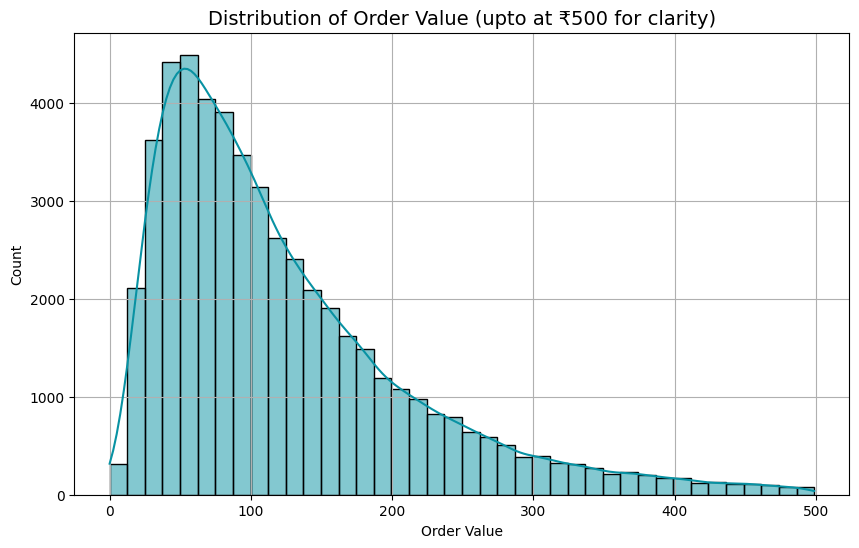

In [87]:
# analysis of order value - which range of price are ordered
plt.figure(figsize=(10, 6))

data = df[df['order_value'] <= 500]['order_value']
sns.histplot(data, bins=40, kde=True, color='#0892A3')
plt.title('Distribution of Order Value (upto at ₹500 for clarity)', fontsize=14)
plt.xlabel('Order Value')
plt.grid()
plt.show()

Conclusion from above graph:-

*   around 3000-4000 order are of price between 50 to 150.
*   1000 order are of price greater than 200.



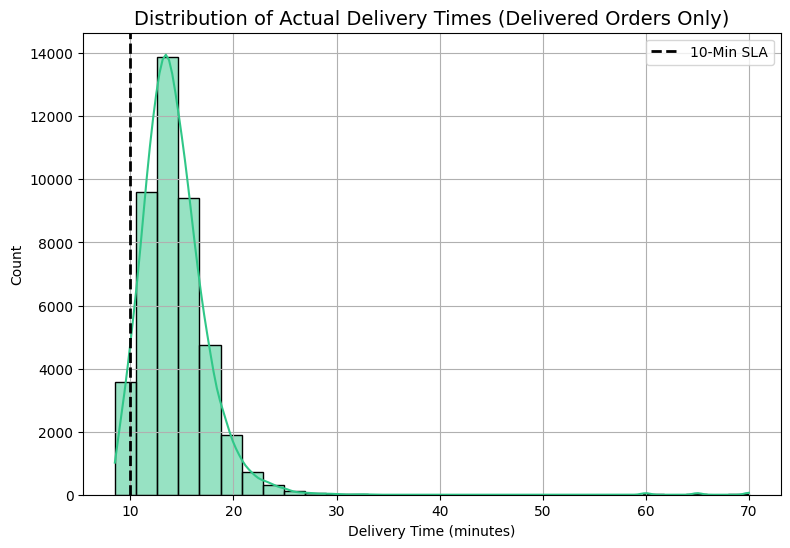

Orders meeting 10-min SLA: 2226 / 44402 (5.0%)


In [88]:
# estimation of orders delivered within the 10 min promise (Delivered orders only)
plt.figure(figsize=(9, 6))

sns.histplot(df_delivered['actual_delivery_mins'], bins=30, kde=True, color='#30C788')
plt.axvline(10, color='black', linestyle='--', linewidth=2, label='10-Min SLA')
plt.title('Distribution of Actual Delivery Times (Delivered Orders Only)', fontsize=14)
plt.xlabel('Delivery Time (minutes)')
plt.grid()
plt.legend()
plt.show()

sla_met = (df_delivered['actual_delivery_mins'] <= 10).sum()
sla_total = len(df_delivered)
print(f"Orders meeting 10-min SLA: {sla_met} / {sla_total} ({sla_met/sla_total*100:.1f}%)")

Conclusion from above graph:-
*   only 2235 out of 44611 (~ 5%) are delievered on time within 10 mins.
*   mostly order are delivered after 10 mins and violate 10 min SLA.


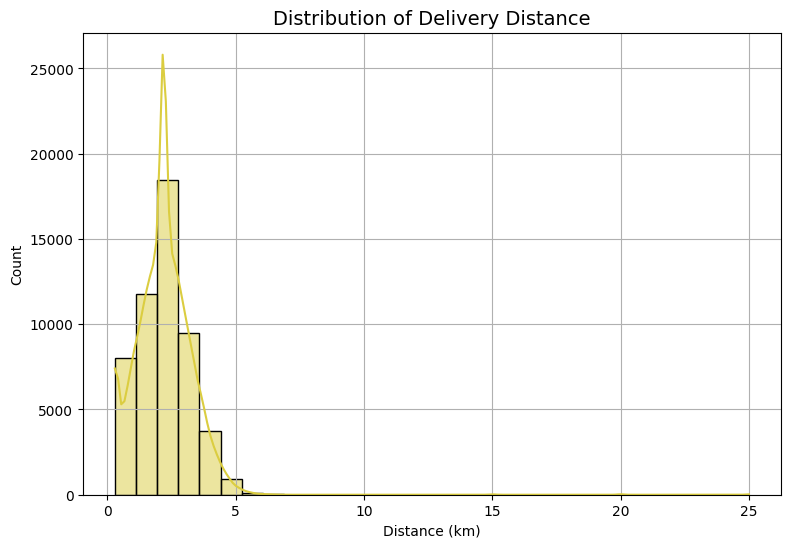

Orders within 5 km of dark store: 52206 / 52500 (99.4%)


In [89]:
# Distribution of delivery distance from dark store
plt.figure(figsize=(9, 6))

sns.histplot(df['distance_km'], bins=30, kde=True, color='#DBCD40')
plt.title('Distribution of Delivery Distance', fontsize=14)
plt.xlabel('Distance (km)')
plt.grid()
plt.show()

dist_under5 = (df['distance_km'] <=5).sum()
total = len(df)
print(f"Orders within 5 km of dark store: {dist_under5} / {total} ({dist_under5/total*100:.1f}%)")

Conclusion from above graph:-
*   52206 orders out of 52500 (~ 99.4%) are ordered within under 5 km.
*   else 0.6% orders are delievered greater than  5km.


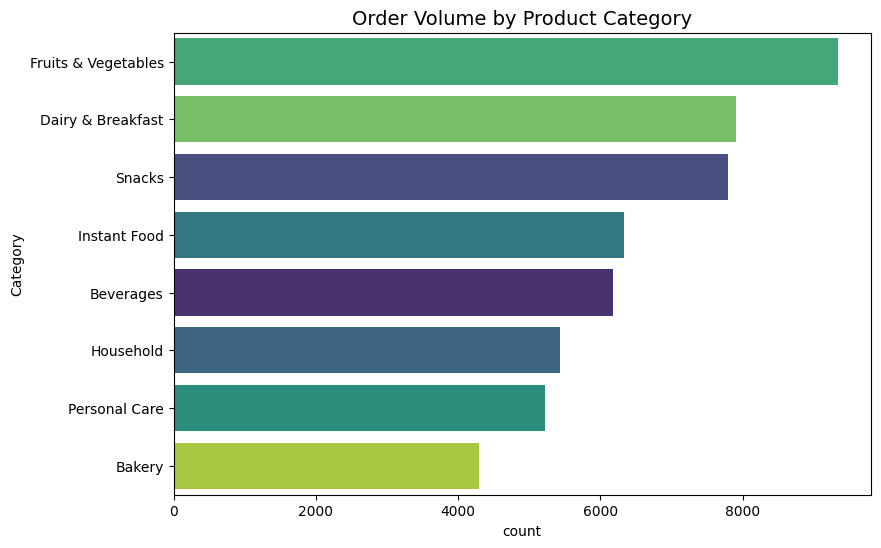

              category  count  percentage
0  Fruits & Vegetables   9339   17.788571
1    Dairy & Breakfast   7907   15.060952
2               Snacks   7791   14.840000
3         Instant Food   6328   12.053333
4            Beverages   6181   11.773333
5            Household   5427   10.337143
6        Personal Care   5229    9.960000
7               Bakery   4298    8.186667


In [90]:
# Distribution of order category among orders
plt.figure(figsize=(9, 6))

sns.countplot(data=df, y='category', hue='category', palette='viridis',
              order=df['category'].value_counts().index, legend=False)
plt.title('Order Volume by Product Category', fontsize=14)
plt.ylabel('Category')
plt.show()

stats = df['category'].value_counts().reset_index()
stats.columns = ['category', 'count']
stats['percentage'] = (stats['count'] / len(df)) * 100

print(stats)

Conclusion from above graph:-

*   The Fruits & Vegetables category are ordered mostly around(~17.78%).
*   and bakery products are ordered less among all category (~8.18%).


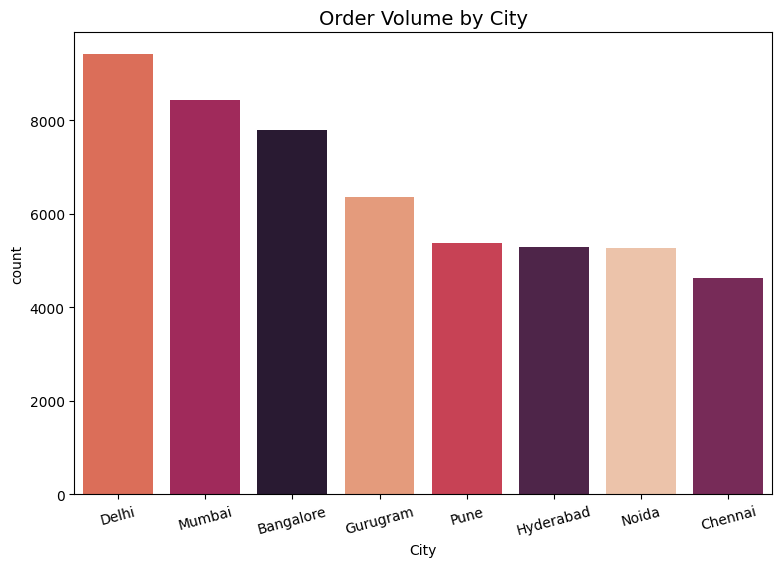


        city  count  percentage
0      Delhi   9404   17.912381
1     Mumbai   8419   16.036190
2  Bangalore   7784   14.826667
3   Gurugram   6365   12.123810
4       Pune   5377   10.241905
5  Hyderabad   5277   10.051429
6      Noida   5261   10.020952
7    Chennai   4613    8.786667


In [91]:
# Distribution of order by city
plt.figure(figsize=(9, 6))

sns.countplot(data=df, x='city', hue='city', palette='rocket',
              order=df['city'].value_counts().index, legend=False)
plt.title('Order Volume by City', fontsize=14)
plt.xlabel('City')
plt.xticks(rotation=15)
plt.show()

print()
city_stats = df['city'].value_counts().reset_index()
city_stats.columns = ['city', 'count']
city_stats['percentage'] = (city_stats['count'] / len(df)) * 100

print(city_stats)

Conclusion from above graph:-

*   The mostly order are delivered in delhi(~17.91%).
*   and the least order if delivered in chennai(~8.78%).





Time-Based Analysis :-

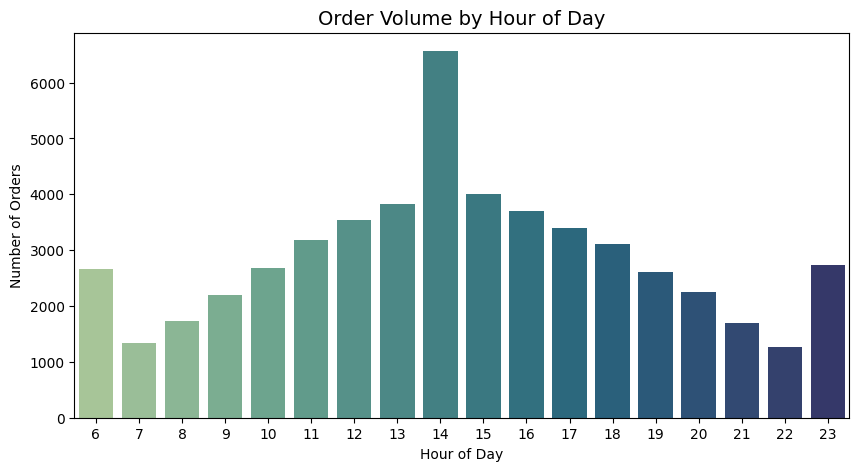

In [92]:
# Order volume by hour of day
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='order_hour', hue='order_hour', palette='crest', legend=False)
plt.title('Order Volume by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.show()

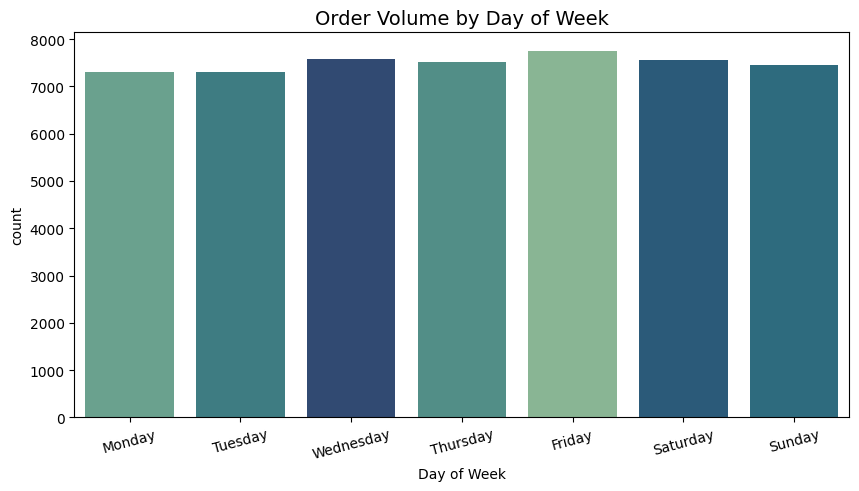

In [93]:
# Order volume by day of week
df['day_of_week'] = df['order_date'].dt.day_name()
df['is_weekend'] = df['order_date'].dt.dayofweek.isin([5, 6])
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='day_of_week', order=day_order, hue='day_of_week',
              palette='crest', legend=False)
plt.title('Order Volume by Day of Week', fontsize=14)
plt.xlabel('Day of Week')
plt.xticks(rotation=15)
plt.show()

Conclusion from above graphs:-

*   Order volume peaks during specific hours (evening/dinner-adjacent hours) -- useful for dark-stores.
*   Weekday vs weekend ordering patterns can guide inventory management.

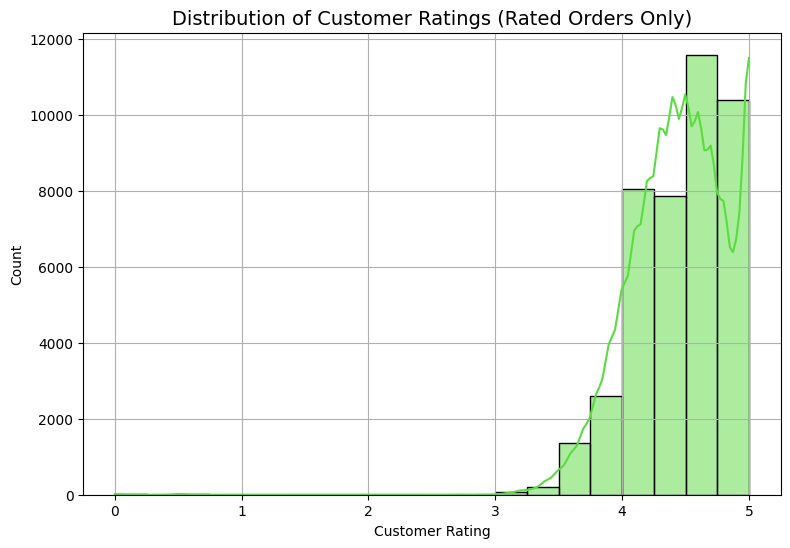


80.3% of orders have a customer rating.
Average rating: 4.45


In [94]:
# Customer Rating distribution -- exclude the -1 "no rating given"
rated = df[df['customer_rating'] != -1]

plt.figure(figsize=(9, 6))
sns.histplot(rated['customer_rating'], bins=20, kde=True, color='#5ADB40')
plt.title('Distribution of Customer Ratings (Rated Orders Only)', fontsize=14)
plt.xlabel('Customer Rating')
plt.grid()
plt.show()


print()
pct_rated = len(rated) / len(df) * 100
print(f"{pct_rated:.1f}% of orders have a customer rating.")
print(f"Average rating: {rated['customer_rating'].mean():.2f}")

Conclusion from above graph:-

*   Most rated orders cluster at the high end (4.0-5.0), typical of delivery-app rating behavior.
*   A meaningful share of orders have no rating at all -- worth checking if this correlates with order_status.

Bivariate Analysis :-

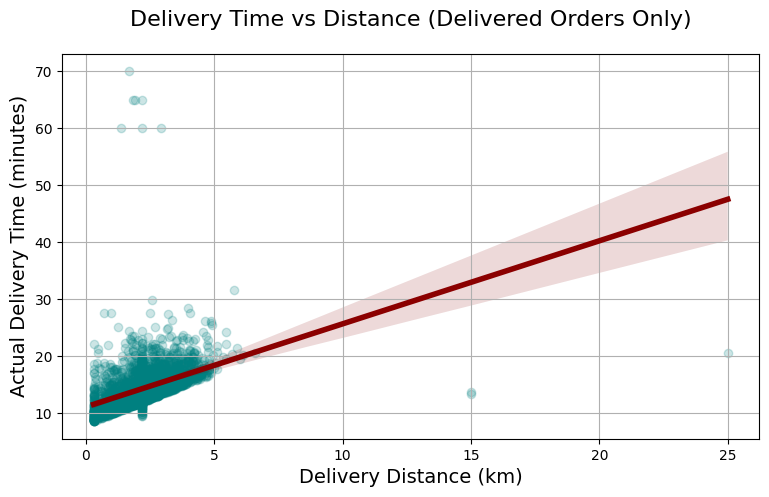

In [95]:
# Delivery Time vs Distance (Delivered Orders Only)
plt.figure(figsize=(9, 5))
sns.regplot(
    data=df_delivered.sample(3000, random_state=42),
    x='distance_km',
    y='actual_delivery_mins',
    scatter_kws={'alpha': 0.2, 'color': '#008080'},
    line_kws={'color': '#8B0000', 'linewidth': 4}
)
plt.title('Delivery Time vs Distance (Delivered Orders Only)', fontsize=16, pad=20)
plt.xlabel('Delivery Distance (km)', fontsize=14)
plt.ylabel('Actual Delivery Time (minutes)', fontsize=14)
plt.grid()
plt.show()

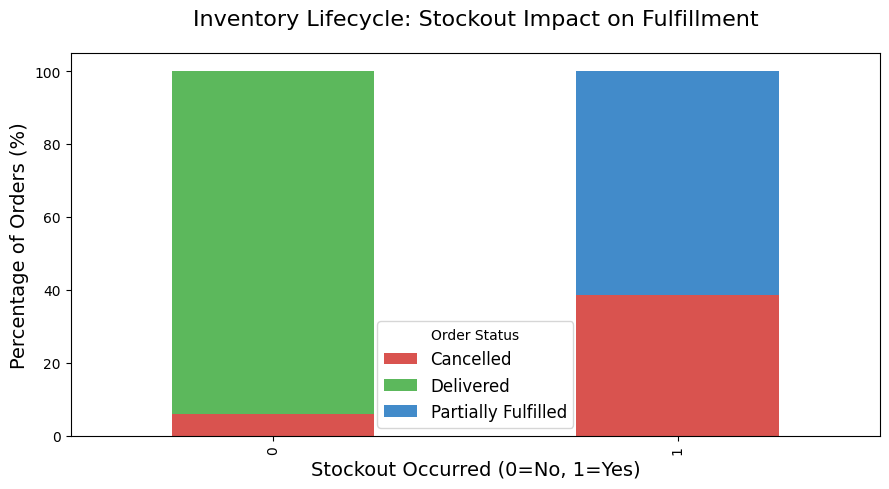

In [96]:
# Compute cancellation rate by city once, reuse for later plots
city_cancel_rate = (
    df.groupby('city')['order_status']
    .apply(lambda x: (x == 'Cancelled').mean() * 100)
    .reset_index(name='cancel_rate')
    .sort_values(by='cancel_rate', ascending=False)
)

# Stockout vs Order Status Breakdown
stockout_status_pct = pd.crosstab(df['stockout_flag'], df['order_status'], normalize='index') * 100

plt.figure(figsize=(9, 5))
stockout_status_pct.plot(
    kind='bar',
    stacked=True,
    color=['#d9534f', '#5cb85c', '#428bca'], # Red, Green, Blue scheme
    ax=plt.gca()
)
plt.title('Inventory Lifecycle: Stockout Impact on Fulfillment', fontsize=16, pad=20)
plt.xlabel('Stockout Occurred (0=No, 1=Yes)', fontsize=14)
plt.ylabel('Percentage of Orders (%)', fontsize=14)
plt.legend(title='Order Status', fontsize=12)
plt.tight_layout()
plt.show()

Conclusion from abve graph :-

*   If the stock is available then, 95% are ordered delivered successfully.
*   If the stock is available then, 5% are ordered cancelled only.
*   If stock is out then moslty ordered are  40% cancelled and 60% partially fulfilled.



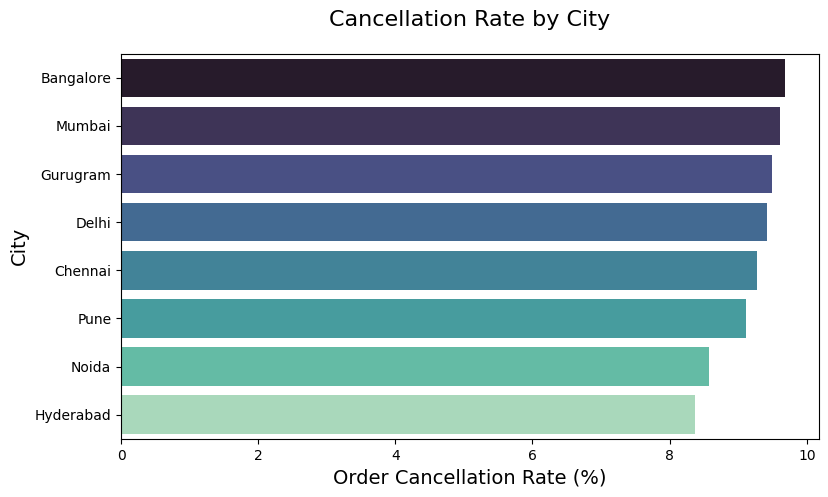

In [97]:
# Cancellation Rate by City
plt.figure(figsize=(9, 5))
sns.barplot(
    data=city_cancel_rate,
    x='cancel_rate',
    y='city',
    hue='city',
    palette='mako',
    legend=False
)
plt.title('Cancellation Rate by City', fontsize=16, pad=20)
plt.xlabel('Order Cancellation Rate (%)', fontsize=14)
plt.ylabel('City', fontsize=14)
plt.show()

Conclusion from abve graph :-

*   the mostly orders are cancelled in banglore city.
*   around 8%-10% are ordered are cancelled in among all cities.



/tmp/ipykernel_665/2153222187.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


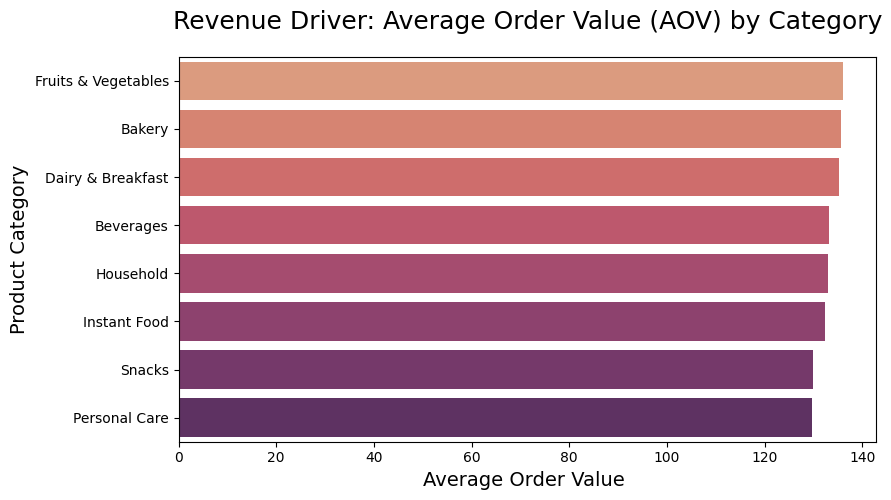

In [98]:
# AOV by Category

category_aov_metrics = df.groupby('category')['order_value'].mean().reset_index().sort_values(by='order_value', ascending=False)

plt.figure(figsize=(9,5))
sns.barplot(
    data=category_aov_metrics,
    x='order_value',
    y='category',
    palette='flare',
)
plt.title('Revenue Driver: Average Order Value (AOV) by Category', fontsize=18, pad=20)
plt.xlabel('Average Order Value ', fontsize=14)
plt.ylabel('Product Category', fontsize=14)
plt.show()

Conclusion from abve graph :-

*   the average order value of fruits & vegetables are greater than among all category (>140).
*   all the categories have teh AOV of 120-140.



Delivery Partner Performance :-

In [99]:
# Delivery partner performance (excluding 'Unknown' -- those are orders with no partner assigned)
partner_perf = (
    df_delivered[df_delivered['delivery_partner_id'] != 'Unknown'].groupby('delivery_partner_id').agg(avg_delivery_mins=('actual_delivery_mins', 'mean'),orders_handled=('order_id', 'count'))
    .sort_values('avg_delivery_mins')
)

qualified = partner_perf[partner_perf['orders_handled'] >= 20]
print("Top 10 fastest delivery partners (min. 20 orders):")
print(qualified.head(10))

print("\nSlowest 10 delivery partners (min. 20 orders):")
print(qualified.tail(10))

Top 10 fastest delivery partners (min. 20 orders):
                     avg_delivery_mins  orders_handled
delivery_partner_id                                   
DP1103                       13.341176             102
DP1111                       13.441818             110
DP1097                       13.445000             120
DP1383                       13.491011              89
DP1227                       13.574576             118
DP1044                       13.623529             119
DP1289                       13.683168             101
DP1141                       13.701667             120
DP1115                       13.704630             108
DP1028                       13.714655             116

Slowest 10 delivery partners (min. 20 orders):
                     avg_delivery_mins  orders_handled
delivery_partner_id                                   
DP1251                       15.112977             131
DP1005                       15.129091             110
DP1305               

Category Preference by City :-

category     Bakery  Beverages  Dairy & Breakfast  Fruits & Vegetables  \
city                                                                     
Bangalore  8.363309  11.305242          15.262076            17.921377   
Chennai    8.627791  11.489269          14.871017            18.101019   
Delhi      8.262442  11.463207          15.089324            18.460230   
Gurugram   8.043991  11.893166          15.459544            17.219167   
Hyderabad  8.205420  11.805950          14.686375            18.116354   
Mumbai     8.088847  12.257988          15.025537            17.365483   
Noida      8.211367  11.404676          14.883102            17.544193   
Pune       7.699461  12.665055          15.008369            17.407476   

category   Household  Instant Food  Personal Care     Snacks  
city                                                          
Bangalore   9.660843     11.793422      10.598664  15.095067  
Chennai    11.077390     11.445914       9.885107  14.502493  
Delhi  

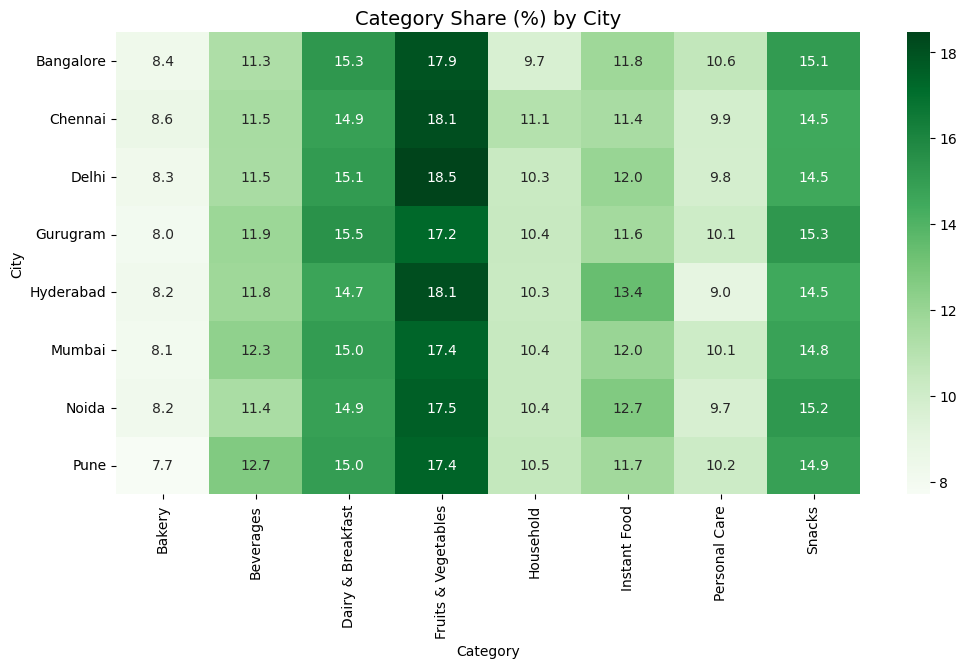

In [100]:
# Category preference by city
category_city = pd.crosstab(df['city'], df['category'], normalize='index') * 100
print(category_city)

plt.figure(figsize=(12, 6))
sns.heatmap(category_city, annot=True, fmt='.1f', cmap='Greens')
plt.title('Category Share (%) by City', fontsize=14)
plt.xlabel('Category')
plt.ylabel('City')
plt.show()

Correlation Between Operational Metrics :-

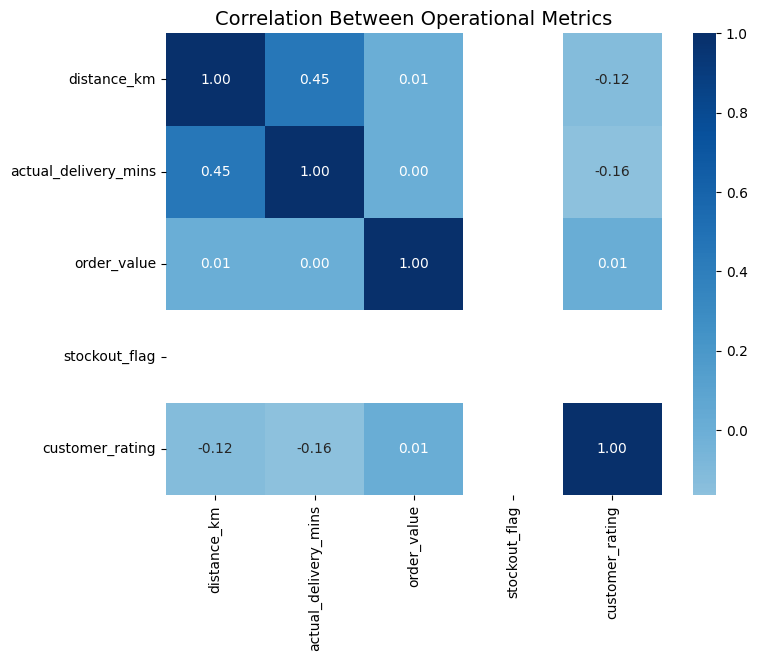

In [101]:
# Correlation heatmap of numeric operational metrics
numeric_cols = ['distance_km', 'actual_delivery_mins', 'order_value', 'stockout_flag', 'customer_rating']
corr_df = df[df['customer_rating'] != -1][numeric_cols]  # exclude the -1 "no rating"

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, cmap='Blues', center=0, fmt='.2f')
plt.title('Correlation Between Operational Metrics', fontsize=14)
plt.show()

**Final Conclusion :-**

*   Only 5% of delivered orders arrived within the 10-minute promise.
*   9.3% of all orders get cancelled overall.
*   When an item is out of stock, cancellation jumps to 38.7% (vs 9.3% normally).
*   2 PM is the busiest hour, with 6,564 orders.
*   Almost every customer (99.9%) reorders.
*   Top 10% of customers bring in only 19.9% of revenue — spending is spread out, not concentrated in a few big spenders.


**Bussiness Insight :-**

 - Biggest Problems -    
    *   Stockouts cause way more cancellations    (38.7%) — this is the #1 fix needed.
    *    Only 5% of orders meet the 10-minute delivery promise — this is a real, ongoing issue.
 - What To Do -
    * Improve stock accuracy and restocking at dark stores, especially in high-demand categories.
    * Either speed up delivery capacity or be more realistic about the "10-minute" promise.
    * Add extra staff/stock between 1–4 PM (peak order time, especially 2 PM).
 - Good things to protect:
   * 99.9% of customers reorder — strong loyalty already exists, make sure it remains same.
   * Payment method doesn't affect order outcome — no issue there.

